In [1]:
# Fitting a function with gradient descent
# A neural network is just a mathematical function. In the most standard kind of neural network, the function:

# Multiplies each input by a number of values. These values are known as parameters
# Adds them up for each group of values
# Replaces the negative numbers with zeros
# This represents one "layer". Then these three steps are repeated, using the outputs of the previous layer as the inputs to the next layer. Initially, the parameters in this function are selected randomly. Therefore a newly created neural network doesn't do anything useful at all -- it's just random!

# To get the function to "learn" to do something useful, we have to change the parameters to make them "better" in some way. We do this using gradient descent.

In [2]:
from ipywidgets import interact
from fastai.basics import *

In [3]:
plt.rc('figure', dpi=90)

In [4]:
def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

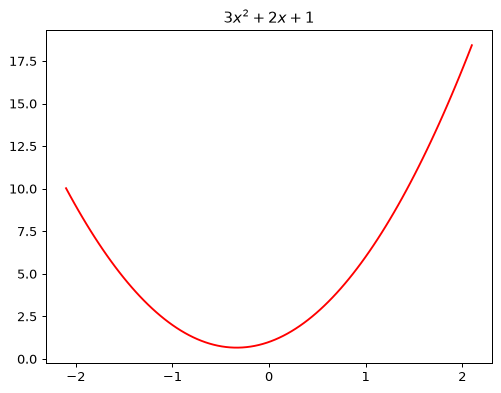

In [5]:
# To learn how gradient descent works, we're going to start by fitting a quadratic:
def f(x): return 3*x**2 + 2*x + 1

plot_function(f, "$3x^2 + 2x + 1$")

In [6]:
# This quadratic is of the form ax**2 + bx + c, with parameters  
# a = 3, b = 2, c = 1
# To make it easier to try out different quadratics for fitting a model to the data 
# we'll create, let's create a function that calculates the value of a point on any 
# quadratic:
def quad(a, b, c, x): return a*x**2 + b*x + c

In [7]:
# If we fix some particular values of a, b, and c, then we'll have made a quadratic. 
# To fix values passed to a function in python, we use the partial function, like so:
def mk_quad(a,b,c): return partial(quad, a,b,c)

In [8]:
# A partial function allows you to fix a certain number of arguments of an existing 
# function and generate a new, specialized function with a simplified signature

# # A standard function with 2 arguments
# def multiply(x, y):
#     return x * y

# # Create a specialized function that always multiplies by 2
# double = partial(multiply, 2)

# # Call the new function with the remaining argument
# print(double(5))  # Output: 10

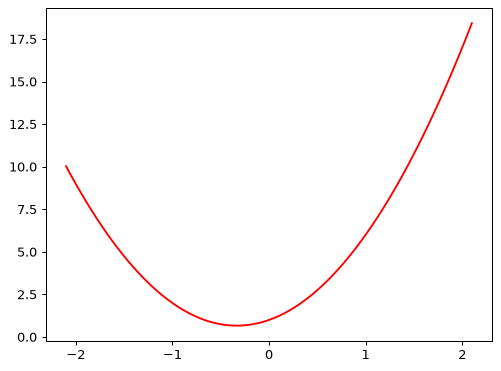

In [9]:
# So for instance, we can recreate our previous quadratic:
f2 = mk_quad(3,2,1)
plot_function(f2)

In [10]:
# Add noise to our quadratic function so that it is closer to actual data
def noise(x, scale): return np.random.normal(scale=scale, size=x.shape)

def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

In [11]:
np.random.seed(42) # So that we get the same noise every time

x = torch.linspace(-2, 2, steps=20)[:,None]
y = add_noise(f(x), 0.15, 1.5)

/tmp/ipykernel_10828/3581951314.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)


In [12]:
# These are tensors. A tensor is just like an array in numpy. A tensor can be a 
# single number (a scalar or rank-0 tensor), a list of numbers (a vector or rank-1 
# tensor), a table of numbers (a matrix or rank-2 tensor), a table of tables of 
# numbers (a rank-3 tensor), and so forth.
x[:5],y[:5]

(tensor([[-2.0000],
         [-1.7895],
         [-1.5789],
         [-1.3684],
         [-1.1579]]),
 tensor([[11.8690],
         [ 6.5433],
         [ 5.9396],
         [ 2.6304],
         [ 1.7947]], dtype=torch.float64))

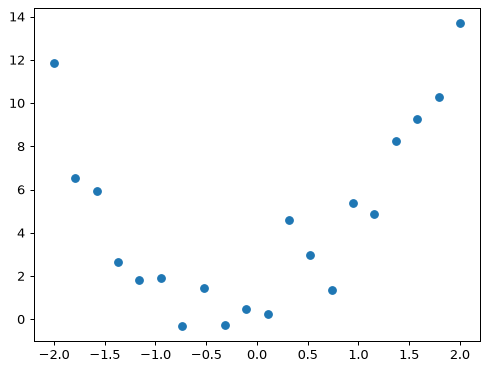

In [13]:
plt.scatter(x,y);

In [14]:
# One approach to now finding a, b, and c is to try a few values and see what fits.
# We create a function which overlays a quadratic on top of our data, along with some
# sliders to change a, b, and c

# The @interact decorator from the ipywidgets library automatically builds user 
# interface controls like sliders, text boxes, and checkboxes in Jupyter Notebooks 
# based on a function's default argument types

@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    plt.scatter(x,y)
    plot_function(mk_quad(a,b,c), ylim=(-3,13))

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [15]:
# mean absolute error -- which is the distance from each data point to the curve:

def mae(preds, acts): return (torch.abs(preds-acts)).mean()

In [16]:
# Update the interactive model to print this mean absolute error 

@interact(a=1.1, b=1.1, c=1.1)
def plot_quad(a, b, c):
    f = mk_quad(a,b,c)
    plt.scatter(x,y)
    loss = mae(f(x), y)
    plot_function(f, ylim=(-3,12), title=f"MAE: {loss:.2f}")

interactive(children=(FloatSlider(value=1.1, description='a', max=3.3000000000000003, min=-1.1), FloatSlider(v…

In [ ]:
# In a modern neural network we'll often have tens of millions of parameters to fit, 
# or more, and thousands or millions of data points to fit them to. We can use 
# calculus to figure out, for each parameter, whether we should increase or 
# decrease it.

In [ ]:
# Automating gradient descent

# if we know the gradient of our mae() function with respect to our parameters, a, b, 
# and c, then that means we know how adjusting (for instance) a will change the value 
# of mae(). If, say, a has a negative gradient, then we know that increasing a will 
# decrease mae(). Then we know that's what we need to do, since we trying to make 
# mae() as low as possible.

# So, we find the gradient of mae() for each of our parameters, and then adjust our 
# parameters a bit in the opposite direction to the sign of the gradient.

In [17]:
# We need a function that takes all the parameters a, b, and c as a single 
# vector input, and returns the value mae() based on those parameters:

def quad_mae(params):
    f = mk_quad(*params)
    return mae(f(x), y)

In [26]:
quad_mae([1.1, 1.1, 1.1])

tensor(2.4219, dtype=torch.float64)

In [37]:
# We pick some random values as our staring point for our parameters. We put them
# all into a single tensor (rank 1 / 1 D tensor)
abc = torch.tensor([1.1,1.1,1.1])

In [38]:
# To tell PyTorch that we want it to calculate gradients for these parameters, we 
# need to call requires_grad_():
abc.requires_grad_()

tensor([1.1000, 1.1000, 1.1000], requires_grad=True)

In [39]:
# We are trying to minimise loss in our gradient descent
loss = quad_mae(abc)
loss

tensor(2.4219, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [40]:
# To get PyTorch to now calculate the gradients, we need to call backward()

# In PyTorch, the tensor.backward() method calculates the gradients of a tensor with 
# respect to the graph leaves (the model's weights and biases) using the chain rule. 
# This process is known as backpropagation

loss.backward()

In [41]:
# The gradients will be stored in an attribute called grad:
abc.grad

# .grad is a tensor attribute that stores the computed gradients (derivatives) of an 
# output (like a loss function) with respect to that specific leaf tensor.

tensor([-1.3529, -0.0316, -0.5000])

In [42]:
# The above tells that if we increase a, the loss will go down
# If I increase b, the loss will go down, and same with c

# But by how much?

# If we increase a by 1 unit (say 1.1 -> 2.1), our loss will go down by -1.3


In [43]:
# According to these gradients, all our parameters are a little low. So let's 
# increase them a bit. If we subtract the gradient, multiplied by a small number, 
# that should improve them a bit:

with torch.no_grad():
    abc -= abc.grad*0.01
    loss = quad_mae(abc)

print(f'loss={loss:.2f}')   

loss=2.40


In [44]:
# Yes, our loss has gone down!

# The "small number" we multiply is called the learning rate, and is the most important 
# hyper-parameter to set when training a neural network.

In [45]:
# BTW, you'll see we had to wrap our calculation of the new parameters in with 
# torch.no_grad(). That disables the calculation of gradients for any operations 
# inside that context manager. We have to do that, because abc -= abc.grad*0.01 
# isn't actually part of our quadratic model, so we don't want derivitives to include 
# that calculation.

# We can use a loop to do a few more iterations of this:
for i in range(10):
    loss = quad_mae(abc)
    loss.backward()
    with torch.no_grad(): 
        abc -= abc.grad*0.01
    print(f'step={i}; loss={loss:.2f}')
    print(abc, abc.grad)

step=0; loss=2.40
tensor([1.1406, 1.1009, 1.1150], requires_grad=True) tensor([-2.7058, -0.0632, -1.0000])
step=1; loss=2.36
tensor([1.1812, 1.1019, 1.1300], requires_grad=True) tensor([-4.0587, -0.0947, -1.5000])
step=2; loss=2.30
tensor([1.2353, 1.1032, 1.1500], requires_grad=True) tensor([-5.4116, -0.1263, -2.0000])
step=3; loss=2.21
tensor([1.3029, 1.1047, 1.1750], requires_grad=True) tensor([-6.7645, -0.1579, -2.5000])
step=4; loss=2.11
tensor([1.3841, 1.1066, 1.2050], requires_grad=True) tensor([-8.1175, -0.1895, -3.0000])
step=5; loss=1.98
tensor([1.4788, 1.1088, 1.2400], requires_grad=True) tensor([-9.4704, -0.2211, -3.5000])
step=6; loss=1.85
tensor([1.5857, 1.1125, 1.2790], requires_grad=True) tensor([-10.6892,  -0.3684,  -3.9000])
step=7; loss=1.72
tensor([1.7029, 1.1191, 1.3210], requires_grad=True) tensor([-11.7208,  -0.6526,  -4.2000])
step=8; loss=1.58
tensor([1.8291, 1.1273, 1.3650], requires_grad=True) tensor([-12.6183,  -0.8211,  -4.4000])
step=9; loss=1.46
tensor([1.

In [ ]:
# our loss keeps going down!

# If you keep running this loop for long enough however, you'll see that the loss 
# eventually starts increasing for a while. That's because once the parameters get 
# close to the correct answer, our parameter updates will jump right over the correct 
# answer! To avoid this, we need to decrease our learning rate as we train. This is 
# done using a learning rate schedule, and can be automated in most deep learning 
# frameworks, such as fastai and PyTorch.

In [ ]:
# The trick is that a neural network is a very expressive function. In fact -- it's infinitely expressive. A neural network can approximate any computable function, given enough parameters. A "computable function" can cover just about anything you can imagine: understand and translate human speech; paint a picture; diagnose a disease from medical imaging; write an essay; etc...

# The way a neural network approximates a function actually turns out to be very simple. The key trick is to combine two extremely basic steps:

# Matrix multiplication, which is just multiplying things together and then adding them up
# The function max(x, 0), which simply replaces all negative numbers with zero.
# In PyTorch, the function max(x, 0) is written as np.clip(x,0). The combination of a linear function and this max() is called a rectified linear function, and it can be implemented like this:

In [46]:
# But how do we represent more complicated real-life functions?
# We can create an infinitely flexible function from a ReLU function

# Rectified Linear Unit
def rectified_linear(m, b, x):
    y = m * x + b
    return torch.clip(y, 0.0)
    # torch.clip() takes output y and if its less than that number passed, it turns
    # into that number
    # So if it takes anything negative, it will make it 0

In [47]:
# torch.clip() is an exact alias for torch.clamp(). It restricts all elements in a 
# tensor to a defined [min, max] range.Elements below the minimum bound are set to 
# min, and elements above the maximum bound are set to max.
    
# torch.clip(input, min=None, max=None, *, out=None) -> Tensor
# input: The target tensor to clip.
# min: The lower bound. Values smaller than this are replaced.
# max: The upper bound. Values larger than this are replaced.
# out: An optional destination tensor to store the results.

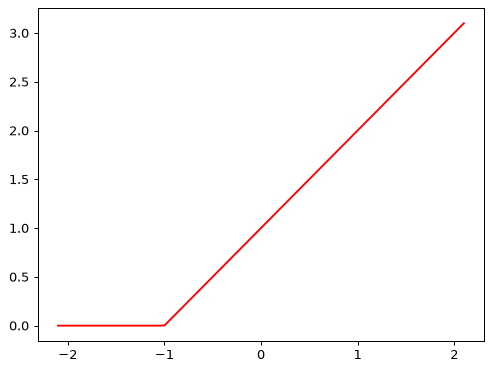

In [48]:
plot_function(partial(rectified_linear, 1, 1))

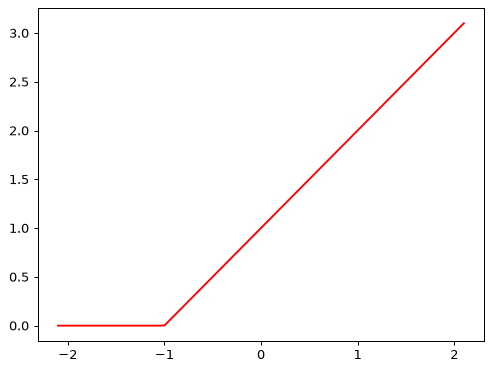

In [49]:
# BTW, instead of torch.clip(y, 0.), we can instead use F.relu(x), which does exactly 
# the same thing. In PyTorch, F refers to the torch.nn.functional module.

import torch.nn.functional as F

def rectified_linear2(m,b,x): 
    return F.relu(m*x+b)
plot_function(partial(rectified_linear2, 1,1))

In [50]:
# To understand how this function works, try using this interactive version to play around with the parameters m and b:

@interact(m=1.5, b=1.5)
def plot_relu(m, b):
    plot_function(partial(rectified_linear, m,b), ylim=(-1,4))

interactive(children=(FloatSlider(value=1.5, description='m', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [51]:
# m changes the slope, and b changes where the "hook" appears. This function doesn't 
# do much on its own, but look what happens when we add two of them together:

def double_relu(m1,b1,m2,b2,x):
    return rectified_linear(m1,b1,x) + rectified_linear(m2,b2,x)

In [52]:
@interact(m1=-1.5, b1=-1.5, m2=1.5, b2=1.5)
def plot_double_relu(m1, b1, m2, b2):
    plot_function(partial(double_relu, m1,b1,m2,b2), ylim=(-1,6))

interactive(children=(FloatSlider(value=-1.5, description='m1', max=1.5, min=-4.5), FloatSlider(value=-1.5, de…

In [ ]:
# with enough of these rectified linear functions added together, you could 
# approximate any function with a single input, to whatever accuracy you like! 
# Any time the function doesn't quite match, you can just add a few more additions 
# to the mix to make it a bit closer. As an experiment, perhaps you'd like to try 
# creating your own plot_triple_relu interactive function, and maybe even include 
# the scatter plot of our data from before, to see how close you can get?

# This exact same approach can be expanded to functions of 2, 3, or more parameters.